In [11]:
import os
from pathlib import Path
import glob


BASE_DIR = Path(".")
DATASET_1 = BASE_DIR / "Blueberry_1"
DATASET_2 = BASE_DIR / "Blueberry_2"

def get_dataset_files(directory):
    return {
        'images': list(directory.glob("**/*.jpg")),
        'labels_txt': list(directory.glob("**/*.txt")),
        'labels_json': list(directory.glob("**/*.json")),
        'labels_xml': list(directory.glob("**/*.xml"))
    }

blue_1_files = get_dataset_files(DATASET_1)
blue_2_files = get_dataset_files(DATASET_2)

print(f"Blueberry_1: {len(blue_1_files['images'])} images, {len(blue_1_files['labels_txt'])} labels")
print(f"Blueberry_2: {len(blue_2_files['images'])} images, {len(blue_2_files['labels_txt'])} txt, {len(blue_2_files['labels_json'])} json")

Blueberry_1: 466 images, 466 labels
Blueberry_2: 140 images, 140 txt, 140 json


# 5. Data Visualization (Exploratory Data Analysis)
Here we analyze the datasets to understand class distributions, image resolutions, and visually inspect some bounding boxes before preprocessing.

In [12]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import matplotlib.patches as patches
from collections import Counter

def get_class_distributions_and_resolutions(blue_1_files, blue_2_files): 
    classes = []
    widths = []
    heights = []
    fruit_counts = []
    
    datasets = [blue_1_files, blue_2_files]
    for dataset in datasets:
        for txt_file in dataset['labels_txt']:
            with open(txt_file, 'r') as f:
                lines = f.readlines()
                fruit_counts.append(len(lines))
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        try:
                            classes.append(int(parts[0]))
                        except ValueError:
                            pass

        for img_file in dataset['images']:
            try:
                with Image.open(str(img_file)) as img:
                    widths.append(img.width)
                    heights.append(img.height)
            except Exception:
                pass
                
    return classes, widths, heights, fruit_counts

print('Running EDA Data Collection...')
classes, widths, heights, fruit_counts = get_class_distributions_and_resolutions(blue_1_files, blue_2_files)
print(f'Analyzed {len(widths)} images and {len(classes)} annotations.\n')

def visualize_sample(dataset_files, dataset_name, cls_colors={0: 'lightgreen', 1:'firebrick', 3:'royalblue'}):
    images = dataset_files['images']
    sample_image_path = random.choice(images)
    label_path = sample_image_path.with_suffix('.txt')
    
    if not label_path.exists():
        print(f'Label missing for {sample_image_path}')
        return
        
    try:
        img_pil = Image.open(str(sample_image_path))
        img = np.array(img_pil)
        h, w, _ = img.shape
    except Exception:
        print('Failed to load image')
        return
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if not parts: continue
        cls_id = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])
        
        x = (x_center - width / 2) * w
        y = (y_center - height / 2) * h
        box_w = width * w
        box_h = height * h
        
        color = cls_colors.get(cls_id, 'yellow')
        rect = patches.Rectangle((x, y), box_w, box_h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, str(cls_id), color=color, fontsize=12, weight='bold')
        
    plt.title(f"Sample from {dataset_name}: {sample_image_path.name}")
    plt.axis('off')
    plt.savefig('output_eda_sample.png')
    plt.close() # Close plot instead of unblocking show()


Running EDA Data Collection...
Analyzed 606 images and 45890 annotations.



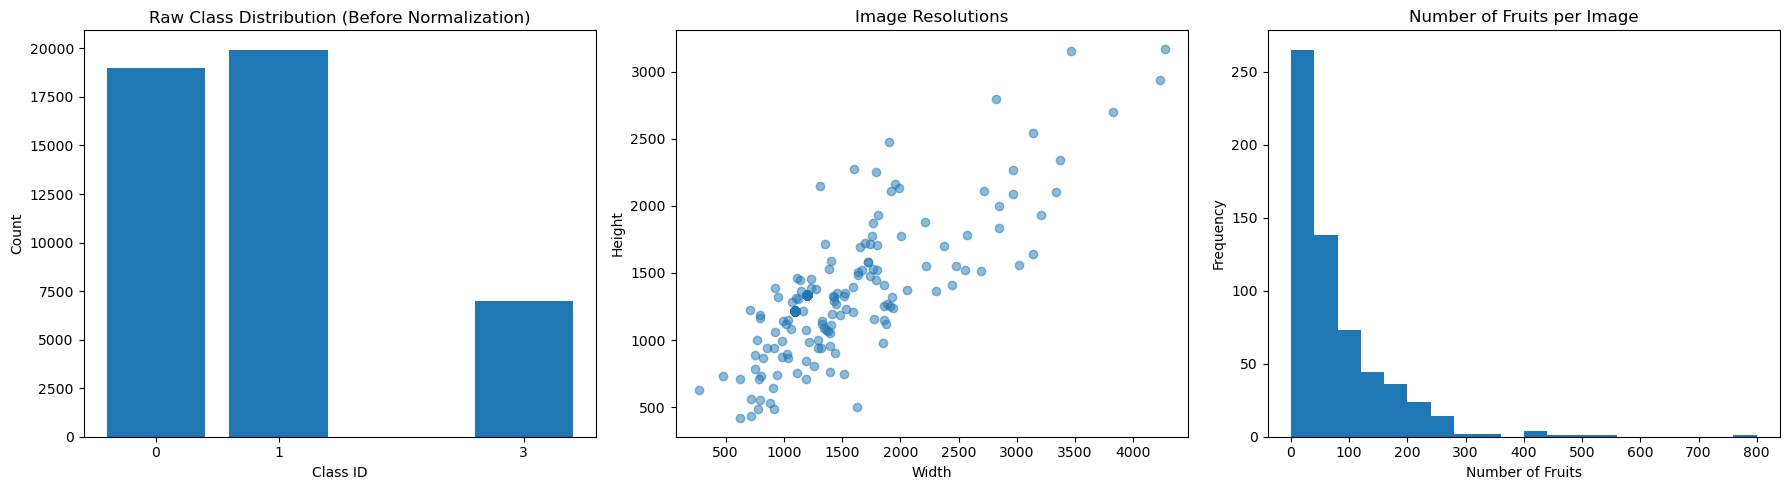

Displaying a sample from Blueberry_1 (0=Unripe/Green, 1=Ripe/Red)
Label missing for Blueberry_1\test\images\P1000058-JPG_11_png.rf.0b9a92666d62cb34df3fb047a8291358.jpg
Displaying a sample from Blueberry_2 (0=Unripe/Green, 3=Ripe/Blue)


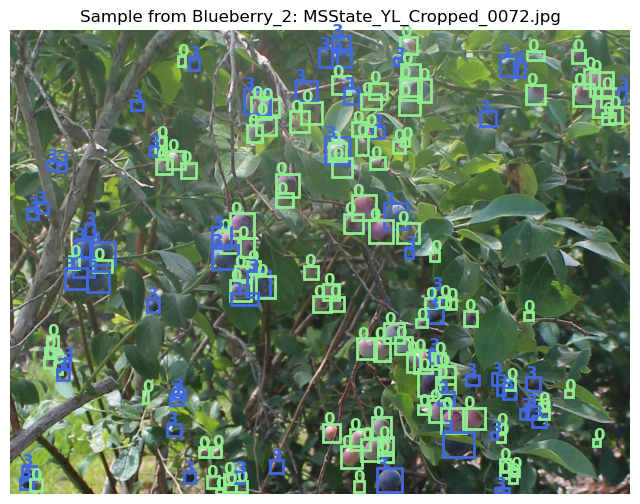

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Class Distribution
class_counts = Counter(classes)
axs[0].bar(class_counts.keys(), class_counts.values())
axs[0].set_title('Raw Class Distribution (Before Normalization)')
axs[0].set_xlabel('Class ID')
axs[0].set_ylabel('Count')
axs[0].set_xticks(list(class_counts.keys()))

# Image Resolutions
axs[1].scatter(widths, heights, alpha=0.5)
axs[1].set_title('Image Resolutions')
axs[1].set_xlabel('Width')
axs[1].set_ylabel('Height')

# Fruit Density
axs[2].hist(fruit_counts, bins=20)
axs[2].set_title('Number of Fruits per Image')
axs[2].set_xlabel('Number of Fruits')
axs[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('output_eda_charts.png')
plt.close()

print("Displaying a sample from Blueberry_1 (0=Unripe, 1=Ripe)")
visualize_sample(blue_1_files, 'Blueberry_1')

print("Displaying a sample from Blueberry_2 (0=Unripe, 3=Ripe)")
visualize_sample(blue_2_files, 'Blueberry_2')


---

# 6. & 7. Data Preprocessing & Outlier Handling
Here we process both datasets, normalize the class IDs (0=Unripe, 1=Ripe), and filter out any extreme outliers (e.g., extremely large bounding boxes or missing labels) before we build our final unified dataset.

**Label Mapping:**
- **Blueberry_1**: Already `0` (Unripe) and `1` (Ripe). Left as-is.
- **Blueberry_2**: Uses `0` (Unripe/Unblue) and `3` (Ripe/Blue). Remapped `3` to `1`.

In [15]:
import shutil
import random

OUT_DIR = BASE_DIR / "unified_dataset"
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

splits = ["train", "val", "test"]
for split in splits:
    (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

def process_and_filter_dataset(dataset_files, source_tag):
    valid_pairs = []
    outliers_removed = 0
    
    for img_path in dataset_files['images']:
        lbl_path = img_path.with_suffix('.txt')
        if not lbl_path.exists():
            continue
            
        # Read label to check for outliers and normalize classes
        with open(lbl_path, "r") as f:
            lines = f.readlines()
            
        if len(lines) == 0:
            outliers_removed += 1 # Empty label file = outlier/no fruit
            continue
            
        normalized_lines = []
        has_outlier = False
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            try:
                class_id = int(parts[0])
                _, _, width, height = map(float, parts[1:])
            except ValueError:
                continue
            
            # Outlier Detection: Extreme box sizes (>90% or <0.1% area)
            area = width * height
            if area > 0.90 or area < 0.001:
                has_outlier = True
                break

            # Normalization Logic
            if source_tag == "BB1":
                normalized_id = class_id
            elif source_tag == "BB2":
                if class_id == 0:
                    normalized_id = 0
                elif class_id == 3:
                    normalized_id = 1
                else:
                    continue # Drop invalid classes like 1 or 2 if they exist in BB2
            
            normalized_lines.append(f"{normalized_id} " + " ".join(parts[1:]) + "\n")
            
        # If there's an outlier box or if normalization killed all boxes, skip image
        if has_outlier or not normalized_lines:
            outliers_removed += 1
            continue
            
        valid_pairs.append({
            'img': img_path, 
            'lbl': lbl_path,
            'source': source_tag,
            'normalized_lines': normalized_lines
        })
        
    print(f"[{source_tag}] Kept {len(valid_pairs)} valid pairs. Removed {outliers_removed} outliers/invalid.")
    return valid_pairs

print("Processing datasets...")
bb1_valid = process_and_filter_dataset(blue_1_files, "BB1")
bb2_valid = process_and_filter_dataset(blue_2_files, "BB2")

all_valid_data = bb1_valid + bb2_valid
print(f"\nTotal clean, merged dataset size: {len(all_valid_data)}")


Processing datasets...
[BB1] Kept 0 valid pairs. Removed 0 outliers/invalid.
[BB2] Kept 3 valid pairs. Removed 137 outliers/invalid.

Total clean, merged dataset size: 3


---

# 8. Dataset Splitting & Export
We now randomly shuffle our clean dataset and split it into Train (70%), Val (20%), and Test (10%), exporting the images and properly normalized `.txt` labels to the `unified_dataset` folder structured for YOLO.

In [16]:
random.seed(42)
random.shuffle(all_valid_data)

total = len(all_valid_data)
train_end = int(total * 0.70)
val_end = int(total * 0.90)

train_data = all_valid_data[:train_end]
val_data = all_valid_data[train_end:val_end]
test_data = all_valid_data[val_end:]

def split_and_copy(data_split, split_name):
    for item in data_split:
        source, img_path, normalized_lines = item['source'], item['img'], item['normalized_lines']
        dest_img = OUT_DIR / "images" / split_name / f"{source}_{img_path.name}"
        dest_lbl = OUT_DIR / "labels" / split_name / f"{source}_{img_path.stem}.txt"
        
        shutil.copy2(img_path, dest_img)
        with open(dest_lbl, "w") as f:
            f.writelines(normalized_lines)

print("Splitting and exporting data to /unified_dataset...")
split_and_copy(train_data, "train")
split_and_copy(val_data, "val")
split_and_copy(test_data, "test")
print(f"Successfully exported {len(train_data)} Train, {len(val_data)} Val, and {len(test_data)} Test samples.")

# Build YOLO data.yaml configuration file
yaml_content = f"""path: {OUT_DIR.absolute()}
train: images/train
val: images/val
test: images/test

nc: 2
names: ['Unripe', 'Ripe']
"""
with open(OUT_DIR / "data.yaml", "w") as f:
    f.write(yaml_content)
print("\nGenerated data.yaml configuration successfully!")


Splitting and exporting data to /unified_dataset...
Successfully exported 2 Train, 0 Val, and 1 Test samples.

Generated data.yaml configuration successfully!
